In [1]:
pip install pandas numpy matplotlib seaborn requests yfinance

Note: you may need to restart the kernel to use updated packages.


In [7]:
import yfinance as yf
import pandas as pd

# Crypto symbols in Yahoo Finance
coins = {
    "BTC-USD": "Bitcoin",
    "ETH-USD": "Ethereum",
    "BNB-USD": "Binance Coin",
    "SOL-USD": "Solana",
    "XRP-USD": "Ripple",
    "ADA-USD": "Cardano",
    "DOGE-USD": "Dogecoin",
    "DOT-USD": "Polkadot",
    "LTC-USD": "Litecoin",
    "AVAX-USD": "Avalanche"
}

all_data = []

for symbol, name in coins.items():
    print(f"Fetching {name}...")
    
    df = yf.download(symbol, period="1y", progress=False)
    
    df = df.reset_index()
    df['crypto_name'] = name
    df['crypto_symbol'] = symbol
    
    df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume',
             'crypto_name', 'crypto_symbol']]
    
    df.columns = ['date', 'open', 'high', 'low', 'close', 'volume',
                  'crypto_name', 'crypto_symbol']
    
    all_data.append(df)

# Combine all coins
final_df = pd.concat(all_data, ignore_index=True)

# Sort data
final_df = final_df.sort_values(['crypto_name', 'date'])

# Round price columns
price_columns = ['open', 'high', 'low', 'close']
final_df[price_columns] = final_df[price_columns].round(3)

# Daily Return
final_df['daily_return'] = final_df.groupby('crypto_name')['close'].pct_change()

# 7-day Moving Average
final_df['ma_7'] = final_df.groupby('crypto_name')['close'].transform(lambda x: x.rolling(7).mean())

# 30-day Volatility
final_df['volatility_30'] = final_df.groupby('crypto_name')['daily_return'].transform(lambda x: x.rolling(30).std())

# Reset index
final_df = final_df.reset_index(drop=True)

final_df.head()

Fetching Bitcoin...
Fetching Ethereum...
Fetching Binance Coin...
Fetching Solana...
Fetching Ripple...
Fetching Cardano...
Fetching Dogecoin...
Fetching Polkadot...
Fetching Litecoin...
Fetching Avalanche...


,date,open,high,low,close,volume,crypto_name,crypto_symbol,daily_return,ma_7,volatility_30
0,2025-03-06,21.729,22.487,20.946,21.029,488753037,Avalanche,AVAX-USD,NaN,NaN,NaN
1,2025-03-07,21.029,21.144,19.778,20.097,552573508,Avalanche,AVAX-USD,-0.044320,NaN,NaN
2,2025-03-08,20.097,21.015,19.485,20.471,308597153,Avalanche,AVAX-USD,0.018610,NaN,NaN
3,2025-03-09,20.471,20.659,17.836,17.958,320273559,Avalanche,AVAX-USD,-0.122759,NaN,NaN
4,2025-03-10,17.956,19.000,16.220,16.286,527953869,Avalanche,AVAX-USD,-0.093106,NaN,NaN


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# convert the yfinance data into csv formate.
final_df.to_csv("crypto_data.csv", index=False)


In [10]:
df.columns


Index(['date', 'open', 'high', 'low', 'close', 'volume', 'crypto_name',
       'crypto_symbol'],
      dtype='object')

In [12]:
final_df[final_df['crypto_name'] == 'Bitcoin'].tail(1)


,date,open,high,low,close,volume,crypto_name,crypto_symbol,daily_return,ma_7,volatility_30
1097,2026-03-06,70878.656,71336.352,70162.836,70645.562,46202535936,Bitcoin,BTC-USD,-0.002761,69142.960857,0.043278


In [13]:
final_df[final_df['crypto_name'] == 'Dogecoin'].tail(1)

,date,open,high,low,close,volume,crypto_name,crypto_symbol,daily_return,ma_7,volatility_30
1829,2026-03-06,0.094,0.094,0.093,0.093,1090174592,Dogecoin,DOGE-USD,-0.010638,0.093714,0.058972


In [53]:
#  For the current price of the crypto.
coin_name = input("Enter coin name: ")

print(final_df[final_df['crypto_name'] == coin_name].tail(1))

Enter coin name:  Bitcoin


           date          open          high           low         close  \
1097 2026-02-27  67476.703125  68125.398438  66645.554688  66645.554688   

           volume crypto_name crypto_symbol  daily_return          ma_7  \
1097  41293897728     Bitcoin       BTC-USD     -0.011982  66631.341518   

      volatility_30  
1097       0.043385  


In [14]:
# Round price columns to 3 decimal places
price_columns = ['open', 'high', 'low', 'close']

final_df[price_columns] = final_df[price_columns].round(3)

final_df.head()

,date,open,high,low,close,volume,crypto_name,crypto_symbol,daily_return,ma_7,volatility_30
0,2025-03-06,21.729,22.487,20.946,21.029,488753037,Avalanche,AVAX-USD,NaN,NaN,NaN
1,2025-03-07,21.029,21.144,19.778,20.097,552573508,Avalanche,AVAX-USD,-0.044320,NaN,NaN
2,2025-03-08,20.097,21.015,19.485,20.471,308597153,Avalanche,AVAX-USD,0.018610,NaN,NaN
3,2025-03-09,20.471,20.659,17.836,17.958,320273559,Avalanche,AVAX-USD,-0.122759,NaN,NaN
4,2025-03-10,17.956,19.000,16.220,16.286,527953869,Avalanche,AVAX-USD,-0.093106,NaN,NaN


In [15]:
final_df.to_csv("crypto_data.csv", index=False)

In [16]:
final_df.to_csv("crypto_data.csv", index=False, date_format='%d/%m/%Y')
# change into date/month/year form

In [19]:
final_df.isnull().sum()

date             0
open             0
high             0
low              0
close            0
volume           0
crypto_name      0
crypto_symbol    0
daily_return     0
ma_7             0
volatility_30    0
dtype: int64

In [18]:
final_df = final_df.fillna(0)

In [20]:
# give the no.of row and columns
final_df.shape

(3660, 11)

In [21]:
# give the columns datatype
final_df.dtypes

date             datetime64[ns]
open                    float64
high                    float64
low                     float64
close                   float64
volume                    int64
crypto_name              object
crypto_symbol            object
daily_return            float64
ma_7                    float64
volatility_30           float64
dtype: object

In [22]:
final_df.describe()

,date,open,high,low,close,volume,daily_return,ma_7,volatility_30
count,3660,3660.000000,3660.000000,3660.000000,3660.000000,3.660000e+03,3660.000000,3660.000000,3660.000000
mean,2025-09-04 12:00:00,10256.125243,10413.581353,10079.579982,10250.680611,9.734177e+09,-0.000799,10118.010387,0.034738
min,2025-03-06 00:00:00,0.088000,0.093000,0.082000,0.088000,6.292935e+07,-0.273129,0.000000,0.000000
25%,2025-06-05 00:00:00,2.095750,2.160250,2.045750,2.091500,5.641757e+08,-0.022008,2.012964,0.025857
50%,2025-09-04 12:00:00,42.959500,43.870000,39.760000,42.960000,1.863809e+09,-0.001479,26.516857,0.037340
75%,2025-12-05 00:00:00,785.739750,797.371250,765.430250,785.739750,6.398979e+09,0.018069,760.346036,0.044835
max,2026-03-06 00:00:00,124752.141000,126198.070000,123196.047000,124752.531000,1.817464e+11,0.335484,122781.400714,0.079145
std,NaN,29823.665936,30253.732959,29342.964578,29811.051299,1.850797e+10,0.039862,29678.901915,0.015468


In [23]:
# give the most expensive avg of coin
final_df.groupby('crypto_name')['close'].mean().sort_values(ascending=False)

crypto_name
Bitcoin         98457.964342
Ethereum         2989.401546
Binance Coin      789.942172
Solana            153.908115
Litecoin           90.174123
Avalanche          19.018899
Polkadot            3.282284
Ripple              2.324374
Cardano             0.612541
Dogecoin            0.177719
Name: close, dtype: float64

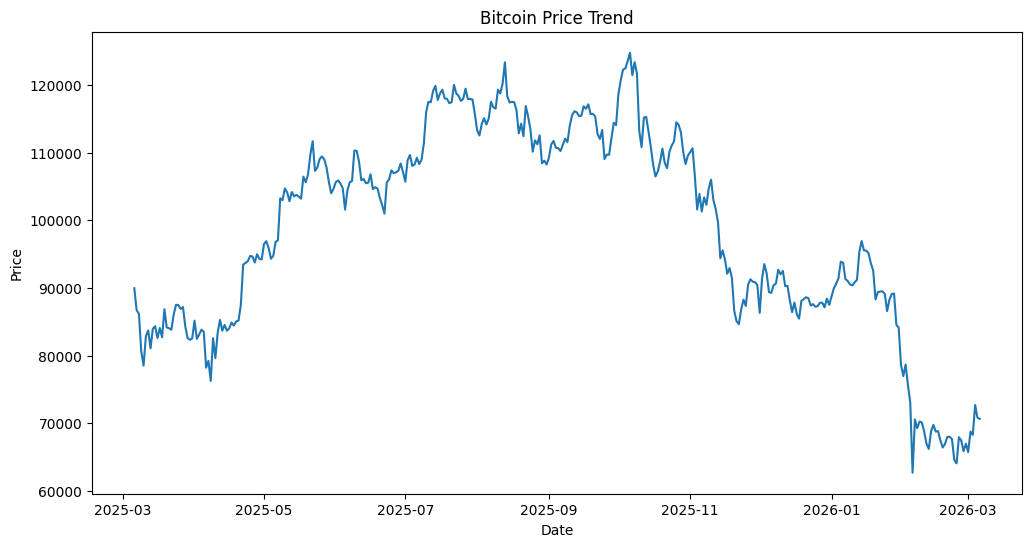

In [24]:
btc = final_df[final_df['crypto_name'] == 'Bitcoin']

plt.figure(figsize=(12,6))
plt.plot(btc['date'], btc['close'])
plt.title("Bitcoin Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

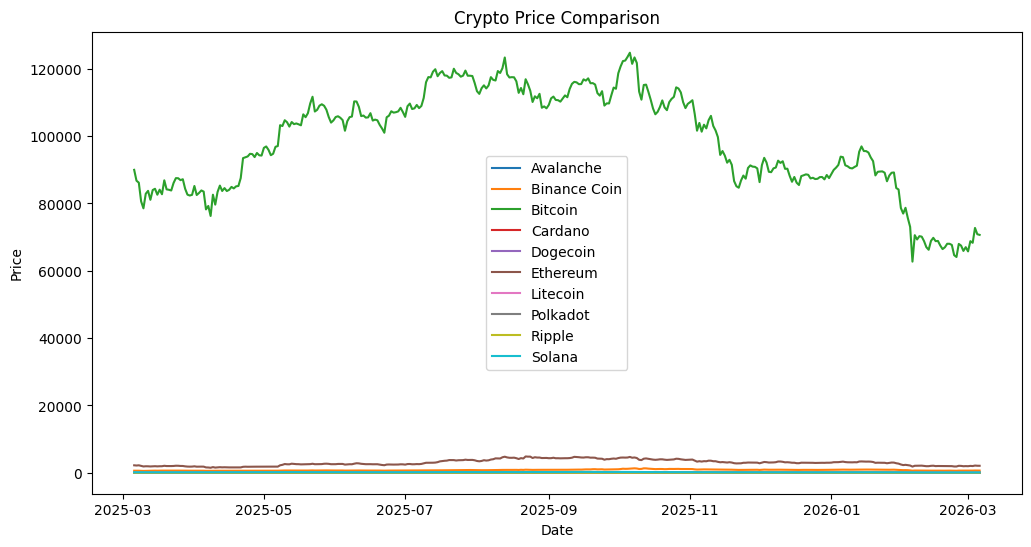

In [25]:
plt.figure(figsize=(12,6))

for coin in final_df['crypto_name'].unique():
    coin_data = final_df[final_df['crypto_name'] == coin]
    plt.plot(coin_data['date'], coin_data['close'], label=coin)

plt.legend()
plt.title("Crypto Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [26]:
# best performing cryptocurrency
first_price = final_df.groupby('crypto_name')['close'].first()
last_price = final_df.groupby('crypto_name')['close'].last()

performance = ((last_price - first_price) / first_price) * 100

performance = performance.sort_values(ascending=False)

performance_df = performance.round(2).to_frame(name='Return (%)')

performance_df

,Return (%)
crypto_name,
Binance Coin,7.45
Ethereum,-6.37
Bitcoin,-21.47
Solana,-38.90
Ripple,-46.16
Litecoin,-46.42
Dogecoin,-53.96
Avalanche,-55.60
Polkadot,-65.56


In [102]:
final_df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'crypto_name',
       'crypto_symbol', 'daily_return', 'ma_7', 'volatility_30'],
      dtype='object')

In [27]:
return_round =  ['daily_return', 'ma_7', 'volatility_30']

final_df[return_round] = final_df[return_round].round(4)

final_df.head()

,date,open,high,low,close,volume,crypto_name,crypto_symbol,daily_return,ma_7,volatility_30
0,2025-03-06,21.729,22.487,20.946,21.029,488753037,Avalanche,AVAX-USD,0.0000,0.0,0.0
1,2025-03-07,21.029,21.144,19.778,20.097,552573508,Avalanche,AVAX-USD,-0.0443,0.0,0.0
2,2025-03-08,20.097,21.015,19.485,20.471,308597153,Avalanche,AVAX-USD,0.0186,0.0,0.0
3,2025-03-09,20.471,20.659,17.836,17.958,320273559,Avalanche,AVAX-USD,-0.1228,0.0,0.0
4,2025-03-10,17.956,19.000,16.220,16.286,527953869,Avalanche,AVAX-USD,-0.0931,0.0,0.0


In [28]:
final_df.to_csv("crypto_data.csv", index=False, date_format='%d/%m/%Y')

In [ ]:
# Time Series Forecasting Models

In [1]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 4.5 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.6 MB 4.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 4.7 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 5.0 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.6 MB 4.9 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.6 MB 5.0 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 5.1 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.6 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 4.7 MB/s  0:00:02
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - ------------------------------

In [29]:
import pandas as pd

final_df['date'] = pd.to_datetime(final_df['date'])
btc = final_df[final_df['crypto_name'] == "Bitcoin"]
btc = btc[['date','close']]
btc = btc.set_index('date')

btc.head()

,close
date,
2025-03-06,89961.727
2025-03-07,86742.672
2025-03-08,86154.594
2025-03-09,80601.039
2025-03-10,78532.000


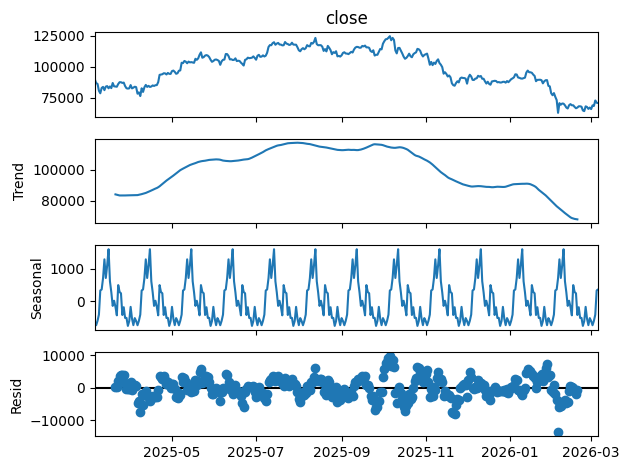

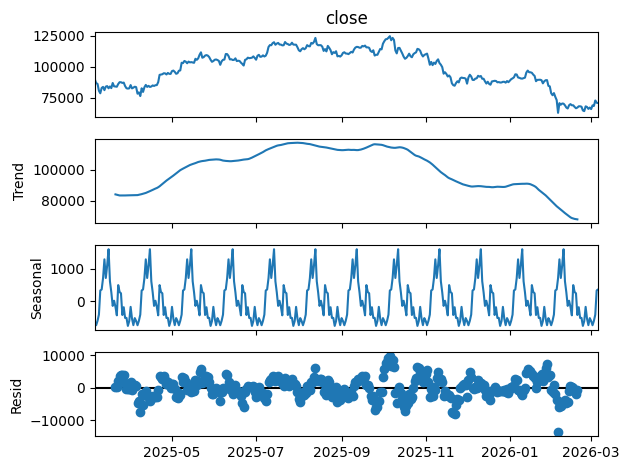

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(btc['close'], model='additive', period=30)

result.plot()

In [31]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(btc['close'], order=(5,1,0))

model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

print(forecast)

2026-03-07    70538.982051
2026-03-08    70540.497069
2026-03-09    70818.370945
2026-03-10    70723.782476
2026-03-11    70718.896876
2026-03-12    70696.094957
2026-03-13    70696.962160
2026-03-14    70713.490107
2026-03-15    70709.614931
2026-03-16    70709.916019
2026-03-17    70707.680682
2026-03-18    70707.692406
2026-03-19    70708.603244
2026-03-20    70708.507812
2026-03-21    70708.572783
2026-03-22    70708.398550
2026-03-23    70708.391646
2026-03-24    70708.436576
2026-03-25    70708.439736
2026-03-26    70708.447075
2026-03-27    70708.435218
2026-03-28    70708.434108
2026-03-29    70708.435925
2026-03-30    70708.436616
2026-03-31    70708.437289
2026-04-01    70708.436568
2026-04-02    70708.436453
2026-04-03    70708.436493
2026-04-04    70708.436558
2026-04-05    70708.436613
Freq: D, Name: predicted_mean, dtype: float64


C:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Forecast file saved!


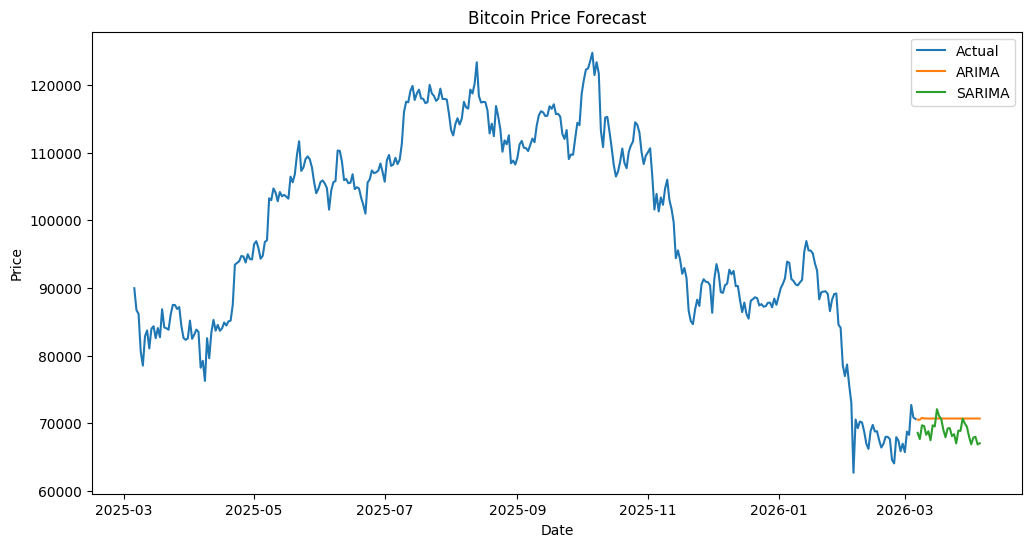

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_df["date"] = pd.to_datetime(final_df["date"])
final_df = final_df.sort_values("date")

crypto_name = "Bitcoin"

crypto_df = final_df[final_df["crypto_name"] == crypto_name]

crypto_df = crypto_df[["date","close"]]
crypto_df.set_index("date", inplace=True)

crypto_df = crypto_df.asfreq("D")

arima_model = ARIMA(crypto_df["close"], order=(5,1,0))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=30)

sarima_model = SARIMAX(
    crypto_df["close"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

sarima_forecast = sarima_fit.forecast(steps=30)

last_date = crypto_df.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

forecast_df = pd.DataFrame({
    "date": future_dates,
    "ARIMA": arima_forecast.values,
    "SARIMA": sarima_forecast.values
})

forecast_df.to_csv("forecast_results.csv", index=False)

print("Forecast file saved!")

plt.figure(figsize=(12,6))

plt.plot(crypto_df.index, crypto_df["close"], label="Actual")

plt.plot(future_dates, arima_forecast, label="ARIMA")

plt.plot(future_dates, sarima_forecast, label="SARIMA")

plt.legend()

plt.title(f"{crypto_name} Price Forecast")

plt.xlabel("Date")
plt.ylabel("Price")

plt.show()